In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.11.0+cpu


In [3]:
#transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#load training data
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training samples: {len(trainset)}")
print(f"Testing samples: {len(testset)}")

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Testing samples: 10000


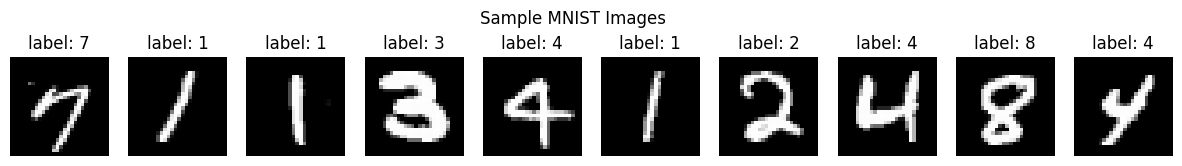

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [7]:
#get one batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

#plot the first 10 images and labels
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"label: {labels[i].item()}")
    axes[i].axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

In [8]:
#define the neural network architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #28x28x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) #14x14x64

        #pooling layer to reduce spatial dimensions
        self.pool = nn.MaxPool2d(2, 2)
        #fully connected layer to output 10 classes
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7) #flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
#create the model and move it to the device
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
)


In [9]:
#now let's train the model
#loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#training loop
epochs = 5
train_losses = []
print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)

        #zero the parameter gradients
        optimizer.zero_grad()
        #forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        #backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Starting training...
Epoch [1/5], Loss: 0.1961
Epoch [2/5], Loss: 0.0599
Epoch [3/5], Loss: 0.0453
Epoch [4/5], Loss: 0.0350
Epoch [5/5], Loss: 0.0292


In [10]:
#evaluate the model on the test set
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 99.15%


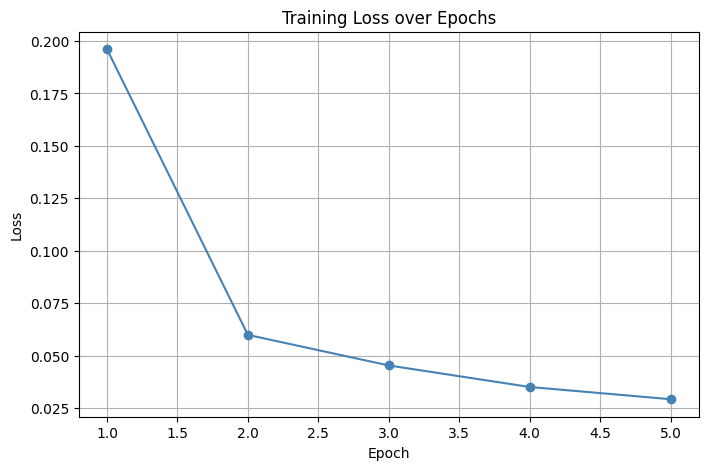

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='steelblue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [12]:
# TRAINING LOSS ANALYSIS
# Epoch 1: 0.1961 → model learning basic patterns
# Epoch 2: 0.0599 → huge drop, model understood digit shapes
# Epoch 3-5: 0.045 → 0.029 → gradual refinement
# Curve shape is perfect — steep drop then flattening = healthy training
# No signs of overfitting — loss consistently decreasing

In [ ]:
#visualize predictions
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[0, i].set_title(f'P:{predicted[i].item()}', color=color)
    
    axes[1, i].imshow(images[i+10].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    color = 'green' if predicted[i+10] == labels[i+10] else 'red'
    axes[1, i].set_title(f'P:{predicted[i+10].item()}', color=color)

plt.suptitle('Green = Correct, Red = Wrong')
plt.show()